In [1]:
from typing import Dict, Any
import matplotlib.pyplot as plt
from pytorch3dunet.datasets.utils import get_train_loaders

In [2]:
loaders_cfg: Dict[str, Any] = {
    "device": "cpu",
    "loaders": {
        "dataset": "StandardHDF5Dataset",
        "batch_size": 2,
        "num_workers": 8,
        "raw_internal_path": "raw",
        "label_internal_path": "labels",
        "global_normalization": True,
        "train": {
            "file_paths": ["/scratch/talks/data/Rmito/train.h5"],
            "roi": [[0, 1], [0, 512], [0, 512]],
            "slice_builder": {
                "name": "SliceBuilder",
                "patch_shape": [1, 256, 256],
                "stride_shape": [1, 256, 256],
                "halo_shape": [0, 0, 0]
            },
            "transformer": {
                "raw": [
                    {"name": "Normalize"},
                    {"name": "ToTensor", "expand_dims": True}
                ],
                "label": [
                    {"name": "Relabel"},
                    {"name": "BlobsToMask"},
                    {"name": "ToTensor", "expand_dims": True}
                ]
            }
        },
        "val": {
            "file_paths": ["/scratch/talks/data/Rmito/val.h5"],
            "roi": [[0, 1], [0, 512], [0, 512]],
            "slice_builder": {
                "name": "SliceBuilder",
                "patch_shape": [1, 256, 256],
                "stride_shape": [1, 256, 256],
                "halo_shape": [0, 0, 0]
            },
            "transformer": {
                "raw": [
                    {"name": "Normalize"},
                    {"name": "ToTensor", "expand_dims": True}
                ],
                "label": [
                    {"name": "Relabel"},
                    {"name": "BlobsToMask"},
                    {"name": "ToTensor", "expand_dims": True}
                ]
            }
        }
    }
}

In [3]:
dataloaders = get_train_loaders(loaders_cfg)

2025-07-25 11:28:35,743 [MainThread] INFO Dataset - Creating training and validation set loaders...
2025-07-25 11:28:35,746 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/Rmito/train.h5...
2025-07-25 11:28:35,747 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 132.24138259887695, global std: 63.98853142720379
2025-07-25 11:28:36,902 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': [1, 256, 256], 'stride_shape': [1, 256, 256], 'halo_shape': [0, 0, 0]}
2025-07-25 11:28:36,979 [MainThread] INFO HDF5Dataset - Number of patches: 4
2025-07-25 11:28:36,981 [MainThread] INFO HDF5Dataset - Loading val set from: /scratch/talks/data/Rmito/val.h5...
2025-07-25 11:28:36,981 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 141.50794219970703, global std: 69.14047187991575
2025-07-25 11:28:37,551 [MainThread] INFO Dataset - Slice builder config: {'name

In [4]:
data_loader_train = dataloaders["train"]

Epoch 1
Raw shape: torch.Size([2, 1, 1, 256, 256]), Label shape: torch.Size([2, 1, 1, 256, 256])


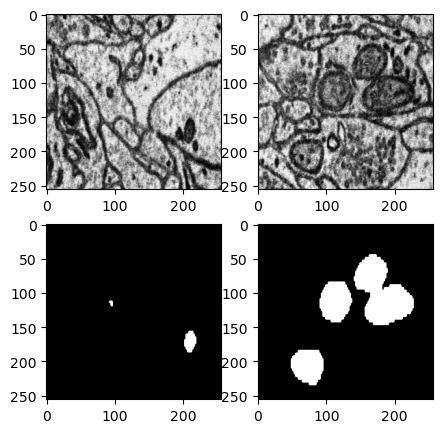

Raw shape: torch.Size([2, 1, 1, 256, 256]), Label shape: torch.Size([2, 1, 1, 256, 256])


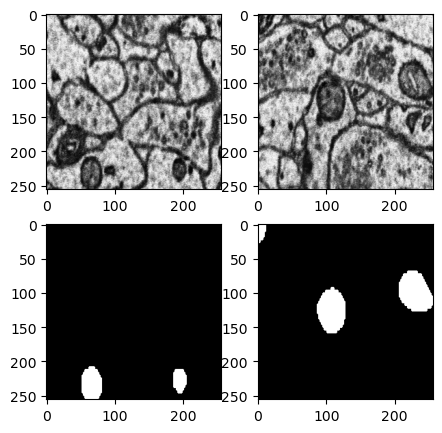

Epoch 2
Raw shape: torch.Size([2, 1, 1, 256, 256]), Label shape: torch.Size([2, 1, 1, 256, 256])


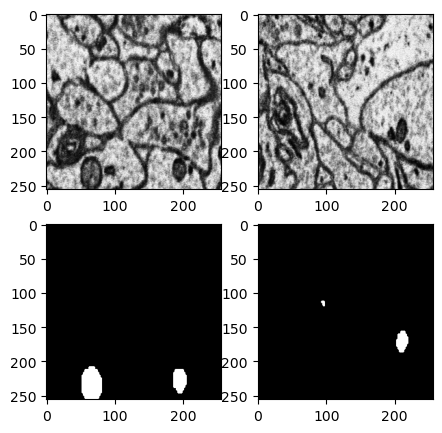

Raw shape: torch.Size([2, 1, 1, 256, 256]), Label shape: torch.Size([2, 1, 1, 256, 256])


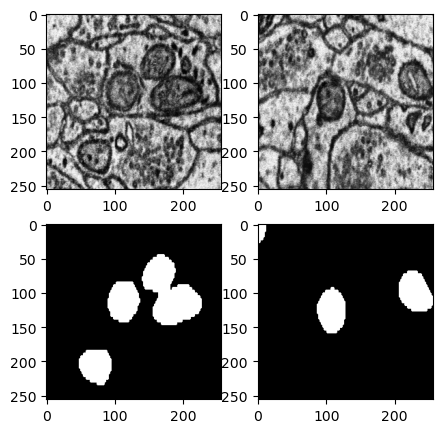

Epoch 3
Raw shape: torch.Size([2, 1, 1, 256, 256]), Label shape: torch.Size([2, 1, 1, 256, 256])


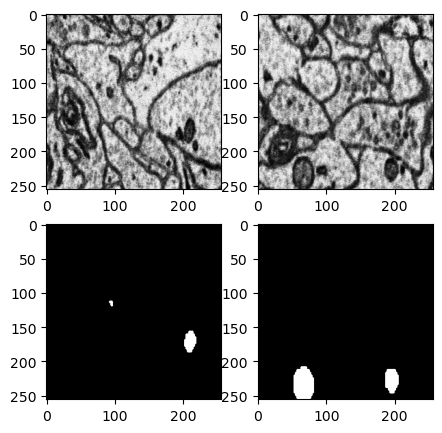

Raw shape: torch.Size([2, 1, 1, 256, 256]), Label shape: torch.Size([2, 1, 1, 256, 256])


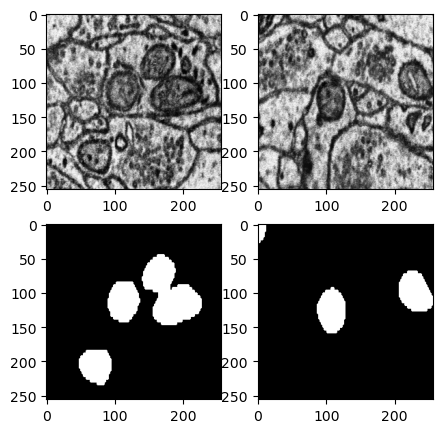

In [5]:
for epoch in range(3):
    print(f"Epoch {epoch + 1}")
    for raw, label in data_loader_train:
        print(f"Raw shape: {raw.shape}, Label shape: {label.shape}")
        _, axs = plt.subplots(2, 2, figsize=(5, 5))
        axs = axs.flatten()

        for i in range(2):
            axs[i].imshow(raw[i].numpy().squeeze(), cmap='gray')
            axs[i + 2].imshow(label[i, 0, :, :].numpy().squeeze(), cmap='gray')
        plt.show()